<a href="https://colab.research.google.com/github/HIPPO1542/THDeepleaningg/blob/main/Bai0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

In [ ]:
# Đường dẫn có sẵn trên các runtime mặc định của Google Colab
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print("Kích thước tập train ban đầu:", df_train.shape)
print("Kích thước tập test ban đầu:", df_test.shape)

Kích thước tập train ban đầu: (19999, 785)
Kích thước tập test ban đầu: (9999, 785)


In [ ]:
# Cột đầu tiên (index 0) là nhãn, các cột còn lại là pixel ảnh
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

print("Kích thước sau khi tách nhãn:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")

Kích thước sau khi tách nhãn:
X_train: (19999, 784) | y_train: (19999,)
X_test: (9999, 784) | y_test: (9999,)


In [ ]:
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa giá trị pixel từ [0, 255] về đoạn [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Chuyển đổi sang numpy array và định hình về kích thước ảnh 28x28 (1 kênh màu)
X_train = X_train.to_numpy().reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.to_numpy().reshape(X_test.shape[0], 28, 28, 1)

print("Kích thước X_train sau chuẩn hóa và reshape:", X_train.shape)
print("Kích thước X_test sau chuẩn hóa và reshape:", X_test.shape)
print('Số lượng class:', len(np.unique(y_train)))

Kích thước X_train sau chuẩn hóa và reshape: (19999, 28, 28, 1)
Kích thước X_test sau chuẩn hóa và reshape: (9999, 28, 28, 1)
Số lượng class: 10


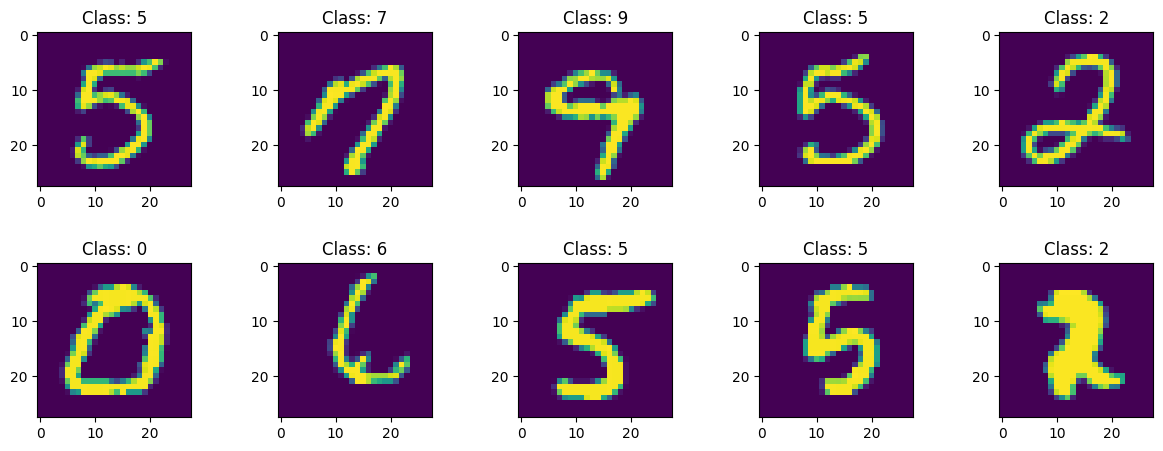

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28)) # Hiển thị ảnh
    ax[i].title.set_text("Class: " + str(y_train.iloc[i])) # Hiển thị nhãn thực tế

plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("Kích thước nhãn sau mã hóa One-Hot:")
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Kích thước nhãn sau mã hóa One-Hot:
y_train: (19999, 10)
y_test: (9999, 10)


In [ ]:
model = Sequential()
model.add(Input(shape=input_shape)) # Tầng đầu vào

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu')) # Tầng chập 1
model.add(MaxPool2D(pool_size=(2, 2))) # Tầng lấy giá trị lớn nhất 1

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu')) # Tầng chập 2
model.add(MaxPool2D(pool_size=(2, 2))) # Tầng lấy giá trị lớn nhất 2

model.add(Flatten()) # Duỗi phẳng ma trận
model.add(Dense(units=10, activation='softmax')) # Tầng liên kết đầy đủ đầu ra

model.summary() # Hiển thị cấu trúc mạng chi tiết

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Biên dịch mô hình với thuật toán tối ưu Adam(điều chỉnh trọng số) và hàm mất mát Categorical Crossentropy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Huấn luyện với 15 Epochs, batch size 128 (đã tối ưu lại từ 126 lỗi trong file)
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - accuracy: 0.8325 - loss: 0.6124 - val_accuracy: 0.9265 - val_loss: 0.2553
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.9518 - loss: 0.1606 - val_accuracy: 0.9550 - val_loss: 0.1360
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9694 - loss: 0.1051 - val_accuracy: 0.9635 - val_loss: 0.1229
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.9734 - loss: 0.0838 - val_accuracy: 0.9715 - val_loss: 0.0913
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.9795 - loss: 0.0663 - val_accuracy: 0.9770 - val_loss: 0.0778
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.9821 - loss: 0.0565 - val_accuracy: 0.9715 - val_loss: 0.0977
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.9834 - loss: 0.0521 - val_accuracy: 0.9775 - val_loss: 0.0665
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.9874 - loss: 0.0418 - 

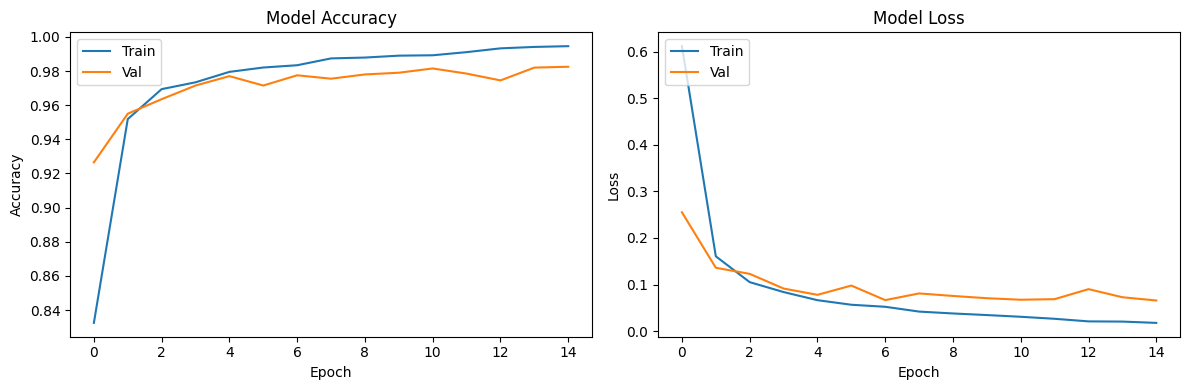

In [ ]:
# Khởi tạo khung hình chứa 2 biểu đồ nằm cạnh nhau
plt.figure(figsize=(12, 4))

# 1. Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# 2. Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('\n--- KẾT QUẢ ĐÁNH GIÁ ---')
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 7ms/step - accuracy: 0.9840 - loss: 0.0560

--- KẾT QUẢ ĐÁNH GIÁ ---
Test loss: 0.056035712361335754
Test accuracy: 0.9839984178543091


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Mảng xác suất dự báo:
 [[5.2352607e-06 1.5601479e-04 9.9983537e-01 7.4748446e-10 5.8340958e-18
  2.4256630e-13 3.3594040e-06 1.8460425e-15 7.9761557e-09 7.2401516e-19]]
Nhãn dự đoán từ mô hình: 2
Nhãn thực tế của dữ liệu: 2


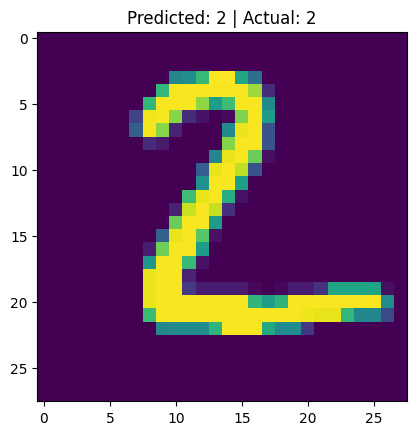

In [ ]:
predict = model.predict(X_test[:1])
print("Mảng xác suất dự báo:\n", predict)

predicted_label = np.argmax(predict)
actual_label = np.argmax(y_test[0])

print(f"Nhãn dự đoán từ mô hình: {predicted_label}")
print(f"Nhãn thực tế của dữ liệu: {actual_label}")

# Hiển thị hình ảnh tương ứng
plt.imshow(X_test[:1].reshape(28, 28))
plt.title(f"Predicted: {predicted_label} | Actual: {actual_label}")
plt.show()

In [ ]:
model.save_weights('cnn.weights.h5')
print("Đã lưu trọng số vào file 'cnn.weights.h5' thành công!")

Đã lưu trọng số vào file 'cnn.weights.h5' thành công!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Nhãn dự đoán (Mô hình nạp lại): 1
Nhãn thực tế: 1


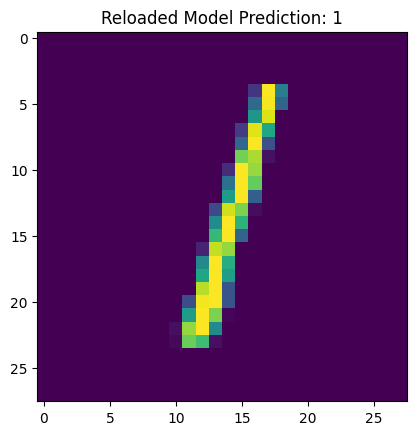

In [ ]:
# 1. Khởi tạo lại cấu trúc mạng trống
model_reloaded = Sequential()
model_reloaded.add(Input(shape=input_shape))
model_reloaded.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2, 2)))
model_reloaded.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2, 2)))
model_reloaded.add(Flatten())
model_reloaded.add(Dense(units=10, activation='softmax'))

# 2. Nạp lại tham số đã lưu
model_reloaded.load_weights('cnn.weights.h5')

# 3. Tiến hành dự báo trên một ảnh khác (ảnh ở index 1)
predict_reloaded = model_reloaded.predict(X_test[1:2])

pred_label_reloaded = np.argmax(predict_reloaded)
actual_label_reloaded = np.argmax(y_test[1])

print(f"Nhãn dự đoán (Mô hình nạp lại): {pred_label_reloaded}")
print(f"Nhãn thực tế: {actual_label_reloaded}")

# Hiển thị hình ảnh kiểm tra
plt.imshow(X_test[1:2].reshape(28, 28))
plt.title(f"Reloaded Model Prediction: {pred_label_reloaded}")
plt.show()